# Applying the Trained Models

This notebook applies trained PINN-MSCNN models to the MODEST Hinode/SP dataset and performs comprehensive analysis including:
- Model loading and inference with uncertainty quantification (Monte Carlo Dropout)
- Spatial maps comparison (predictions vs ground truth)
- Statistical analysis (correlation, RMSE, bias)
- Vertical atmospheric profile comparison
- Multi-model comparison (no physics, WFA only, all physics)
- Error analysis across optical depths

## 0. Prerequisites

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import torch
import astropy.units as u
from pathlib import Path
import sys
from scipy.stats import pearsonr
import pandas as pd
from typing import Dict, Tuple, Optional

# Add parent directories to path
sys.path.append("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN")
from utils.modest_data import ModestData
from models.pinn_mscnn_model import PhysicsInformedMSCNN
from utils.normalizer import MhdNormalizer, StokesNormalizer
from utils.analysis_functions import (
    plot_prediction_comparison,
    compare_models_at_optical_depth,
    plot_mean_vs_optical_depth,
    analyze_error_by_magnitude,
    plot_uncertainty_vs_error,
    plot_jointplot_comparison,
    plot_combined_jointplot
)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# Base images save path
images_base_path = Path("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images")
images_save_path = images_base_path / "modest_analysis/whole_region"

print("✓ All imports successful")

✓ All imports successful


## 1. Load MODEST Data

In [18]:
data_path = Path("/scratchsan/observatorio/juagudeloo/data")

In [19]:
modest = ModestData()
modest.load_all(apply_mask=False)
print("✓ MODEST data loaded successfully")
print(f"  Continuum shape: {modest.continuum.shape}")
print(f"  Stokes I shape: {modest.obs_stokes['I'].shape}")
print(f"  Wavelength points: {len(modest.wl)}")

✓ MODEST data loaded successfully
  Continuum shape: (390, 858)
  Stokes I shape: (390, 858, 112)
  Wavelength points: 112


In [20]:
# Load normalizers
mhd_normalizer = MhdNormalizer()
mhd_normalizer.load(data_path / "normalization_stats/mhd_normalization.json")

stokes_normalizer = StokesNormalizer()
stokes_normalizer.load(data_path / "normalization_stats/stokes_normalization.json")

# Normalize Stokes data
normalized_stokes = stokes_normalizer.transform(modest.obs_stokes)
print("✓ Normalizers loaded and Stokes data normalized")

Per-τ normalization statistics loaded from /scratchsan/observatorio/juagudeloo/data/normalization_stats/mhd_normalization.json
Optical depth levels: 21
Stokes normalization statistics loaded from /scratchsan/observatorio/juagudeloo/data/normalization_stats/stokes_normalization.json
✓ Normalizers loaded and Stokes data normalized


## 2. Visualize FOV and Disk Center

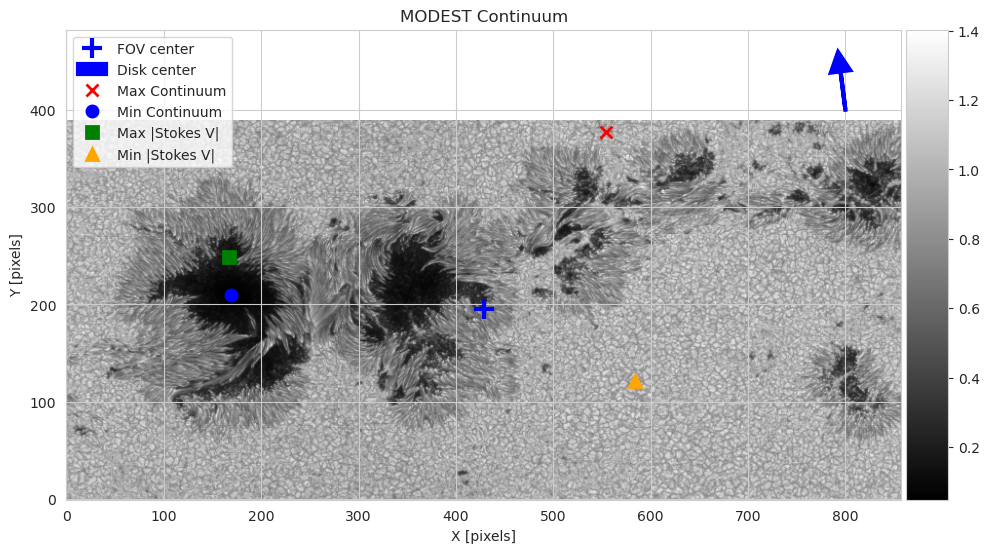

In [21]:
y_center_fov_arcsec = -126.0
x_center_fov_arcsec = 16.0
pixel_scale = 0.32
x_center_fov_pixel = modest.continuum.shape[1] / 2
y_center_fov_pixel = modest.continuum.shape[0] / 2
x_disk_offset_arcsec = 0 - x_center_fov_arcsec
y_disk_offset_arcsec = 0 - y_center_fov_arcsec
x_disk_offset_pixels = x_disk_offset_arcsec / pixel_scale
y_disk_offset_pixels = y_disk_offset_arcsec / pixel_scale
x_disk_center = x_center_fov_pixel + x_disk_offset_pixels
y_disk_center = y_center_fov_pixel + y_disk_offset_pixels
arrow_start_x = 800
arrow_start_y = 400
arrow_dx = x_disk_offset_pixels/10
arrow_dy = y_disk_offset_pixels/10

modest.plot_continuum(
    x_center_fov_pixel=x_center_fov_pixel,
    y_center_fov_pixel=y_center_fov_pixel,
    disk_center=(x_disk_center, y_disk_center),
    arrow_params=(arrow_start_x, arrow_start_y, arrow_dx, arrow_dy)
)

## 3. Load and Compare Multiple Models

We'll load three models trained with different physics regularization:
1. **No Physics**: Pure supervised learning
2. **WFA Only**: Weak-Field Approximation for B_LOS
3. **All Physics**: WFA + Gradient Smoothness

In [22]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Model configurations to compare
model_configs = {
    'no_physics': {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_60_to_100/no_physics/final_model.pth',
        'use_physics': None,
        'lambda_wfa': 0.0,
        'lambda_doppler': 0.0,
        'lambda_physics': 0.0,
        'label': 'No Physics',
        'color': 'blue'
    },
    'wfa_only': {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_60_to_100/wfa_only/final_model.pth',
        'use_physics': 'wfa',
        'lambda_wfa': 0.01,
        'lambda_doppler': 0.0,
        'lambda_physics': 0.0,
        'label': 'WFA Only',
        'color': 'orange'
    },
    'all_physics': {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_60_to_100/all_physics_terms/final_model.pth',
        'use_physics': 'wfa',
        'lambda_wfa': 0.01,
        'lambda_doppler': 0.0,
        'lambda_physics': 0.02,
        'label': 'All Physics',
        'color': 'green'
    }
}

def load_model(config: Dict) -> PhysicsInformedMSCNN:
    """Load a trained PINN-MSCNN model."""
    model = PhysicsInformedMSCNN(
        scales=[1, 2, 3],
        in_channels=2,
        c1_filters=16,
        c2_filters=32,
        kernel_size=5,
        pool_size=2,
        n_linear_layers=4,
        output_features=3*21,
        input_length=112,
        dropout_rate=0.2,
        use_physics=config['use_physics'],
        lambda_wfa=config['lambda_wfa'],
        lambda_doppler=config['lambda_doppler'],
        lambda_physics=config['lambda_physics'],
    ).to(device)
    
    # Load checkpoint
    checkpoint = torch.load(config['path'], map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    return model

# Load all models
models = {}
for name, config in model_configs.items():
    print(f"Loading {config['label']}...")
    models[name] = load_model(config)
    print(f"  ✓ Model loaded successfully")
    if 'test_metrics' in torch.load(config['path'], map_location='cpu'):
        metrics = torch.load(config['path'], map_location='cpu')['test_metrics']
        print(f"  Training metrics: B_LOS RRMSE={metrics.get('blos_rrmse_tau_avg', 'N/A'):.4f}, "
              f"V_LOS RRMSE={metrics.get('vlos_rrmse_tau_avg', 'N/A'):.4f}")

print(f"\n✓ All {len(models)} models loaded")

Using device: cuda
Loading No Physics...
  ✓ Model loaded successfully
  Training metrics: B_LOS RRMSE=inf, V_LOS RRMSE=1.3127
Loading WFA Only...
  ✓ Model loaded successfully
  Training metrics: B_LOS RRMSE=inf, V_LOS RRMSE=1.3170
Loading All Physics...
  ✓ Model loaded successfully
  Training metrics: B_LOS RRMSE=inf, V_LOS RRMSE=1.3163

✓ All 3 models loaded


## 4. Prepare Input Data

In [23]:
# Prepare input tensor
I_t = normalized_stokes["I"]
V_t = normalized_stokes["V"]
inputs = np.stack([I_t, V_t], axis=2)  # Shape: (H, W, 2, nλ)
H, W, Nstokes, Nlambda = inputs.shape

# Convert to torch tensor
inputs_tensor = torch.tensor(inputs, dtype=torch.float32).permute(0, 1, 3, 2)  # (H, W, nλ, 2)
inputs_tensor = inputs_tensor.reshape(H*W, Nstokes, Nlambda).to(device)  # (H*W, 2, nλ)

print(f"Input tensor shape: {inputs_tensor.shape}")
print(f"Total pixels: {H*W:,}")

Input tensor shape: torch.Size([334620, 2, 112])
Total pixels: 334,620


## 5. Run Inference with Uncertainty Quantification

Using Monte Carlo Dropout (30 stochastic forward passes) to estimate prediction uncertainty.

In [24]:
# Run inference for all models
all_predictions = {}
logtau = np.arange(-2, 0.1, 0.1)

print("\n" + "="*70)
for model_name, model in models.items():
    print(f"\nRunning inference for {model_configs[model_name]['label']}...")
    
    # Option 1: Use the model's built-in method directly
    mean_atm, std_atm = model.run_inference_with_uncertainty(
        inputs=inputs_tensor,
        mhd_normalizer=mhd_normalizer,
        batch_size=512,
        stochastic_steps=30,
        H=H,
        W=W,
        n_heights=21,
        verbose=True
    )
    
    # Option 2: Use the wrapper function from analysis_functions (backward compatible)
    # mean_atm, std_atm = run_inference_with_uncertainty(
    #     model, inputs_tensor, mhd_normalizer,
    #     batch_size=512, stochastic_steps=30,
    #     H=H, W=W, n_heights=21
    # )
    
    all_predictions[model_name] = {
        'mean': mean_atm,
        'std': std_atm,
        'label': model_configs[model_name]['label'],
        'color': model_configs[model_name]['color']
    }
    print(f"  T range: {mean_atm['T'].min():.1f} - {mean_atm['T'].max():.1f} K")
    print(f"  Vz range: {mean_atm['Vz'].min():.2f} - {mean_atm['Vz'].max():.2f} km/s")
    print(f"  Bz range: {mean_atm['Bz'].min():.2f} - {mean_atm['Bz'].max():.2f} G")

print("\n" + "="*70)
print("✓ All model inferences complete")



Running inference for No Physics...
Running inference with Monte Carlo Dropout...
  Processed 0/334,620 pixels (0.0%)


  Processed 51,200/334,620 pixels (15.3%)
  Processed 102,400/334,620 pixels (30.6%)
  Processed 153,600/334,620 pixels (45.9%)
  Processed 204,800/334,620 pixels (61.2%)
  Processed 256,000/334,620 pixels (76.5%)
  Processed 307,200/334,620 pixels (91.8%)
  Stochastic predictions shape: torch.Size([30, 334620, 63])


/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/normalizer.py:189: RuntimeWarning: overflow encountered in power
  denorm_tau = sign * (10 ** np.abs(pred_log) - 1.0)


  ✓ Inference complete
    T: mean range [-28295.06, 13047.17], avg std = 339.88
    Vz: mean range [-81.27, 53.43], avg std = 1.61
    Bz: mean range [-7067381522058742872743608320.00, inf], avg std = nan
  T range: -28295.1 - 13047.2 K
  Vz range: -81.27 - 53.43 km/s
  Bz range: -7067381522058742872743608320.00 - inf G

Running inference for WFA Only...
Running inference with Monte Carlo Dropout...
  Processed 0/334,620 pixels (0.0%)
  Processed 51,200/334,620 pixels (15.3%)
  Processed 102,400/334,620 pixels (30.6%)
  Processed 153,600/334,620 pixels (45.9%)
  Processed 204,800/334,620 pixels (61.2%)
  Processed 256,000/334,620 pixels (76.5%)
  Processed 307,200/334,620 pixels (91.8%)
  Stochastic predictions shape: torch.Size([30, 334620, 63])
  ✓ Inference complete
    T: mean range [-20954.74, 11546.90], avg std = 197.33
    Vz: mean range [-34.90, 31.59], avg std = 1.10
    Bz: mean range [-67428897923707969732608.00, 27351758342717440.00], avg std = inf
  T range: -20954.7 - 11

## 6. Analysis Functions

Analysis functions have been moved to `utils/analysis_functions.py` for reusability.

## 7. Single Model Analysis

Analyze each model individually at a specific optical depth.

In [25]:
modest_logtau = list(modest.spinor_atm["T"].keys())

/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Summary for No Physics: Line-of-sight Magnetic Field at log(τ)=-2.0
Pearson R:   -0.0000 (p-value: 9.96e-01)
RMSE:        1198852352.000 G
Bias:        -2916019.250 G
Mean σ:      15620494.000 G
Median σ:    3.745 G

✓ Saved comparison plot for No Physics at log(tau)=-2.0 for Bz

Summary for WFA Only: Line-of-sight Magnetic Field at log(τ)=-2.0
Pearson R:   0.0067 (p-value: 9.62e-05)
RMSE:        73968.586 G
Bias:        -615.220 G
Mean σ:      2683.568 G
Median σ:    1.539 G

✓ Saved comparison plot for WFA Only at log(tau)=-2.0 for Bz

Summary for All Physics: Line-of-sight Magnetic Field at log(τ)=-2.0
Pearson R:   0.0040 (p-value: 1.95e-02)
RMSE:        615235073343488.000 G
Bias:        -1906639765504.000 G
Mean σ:      10249975103488.000 G
Median σ:    4.065 G

✓ Saved comparison plot for All Physics at log(tau)=-2.0 for Bz

Summary for No Physics: Line-of-sight Velocity at log(τ)=-2.0
Pearson R:   -0.0697 (p-value: 0.00e+00)
RMSE:        2.720 km/s
Bias:        -0.114 km/s
Mean

/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:88: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean(difference**2))



Summary for No Physics: Line-of-sight Magnetic Field at log(τ)=-0.8
Pearson R:   0.0049 (p-value: 4.65e-03)
RMSE:        inf G
Bias:        -53666088809922560.000 G
Mean σ:      inf G
Median σ:    7.053 G

✓ Saved comparison plot for No Physics at log(tau)=-0.8 for Bz

Summary for WFA Only: Line-of-sight Magnetic Field at log(τ)=-0.8
Pearson R:   -0.0042 (p-value: 1.45e-02)
RMSE:        4878351360.000 G
Bias:        -12673710.000 G
Mean σ:      68107656.000 G
Median σ:    14.491 G

✓ Saved comparison plot for WFA Only at log(tau)=-0.8 for Bz

Summary for All Physics: Line-of-sight Magnetic Field at log(τ)=-0.8
Pearson R:   -0.0037 (p-value: 3.28e-02)
RMSE:        inf G
Bias:        -32827352018845696.000 G
Mean σ:      inf G
Median σ:    4.972 G

✓ Saved comparison plot for All Physics at log(tau)=-0.8 for Bz

Summary for No Physics: Line-of-sight Velocity at log(τ)=-0.8
Pearson R:   -0.1400 (p-value: 0.00e+00)
RMSE:        3.282 km/s
Bias:        0.034 km/s
Mean σ:      1.393 km/s
Me

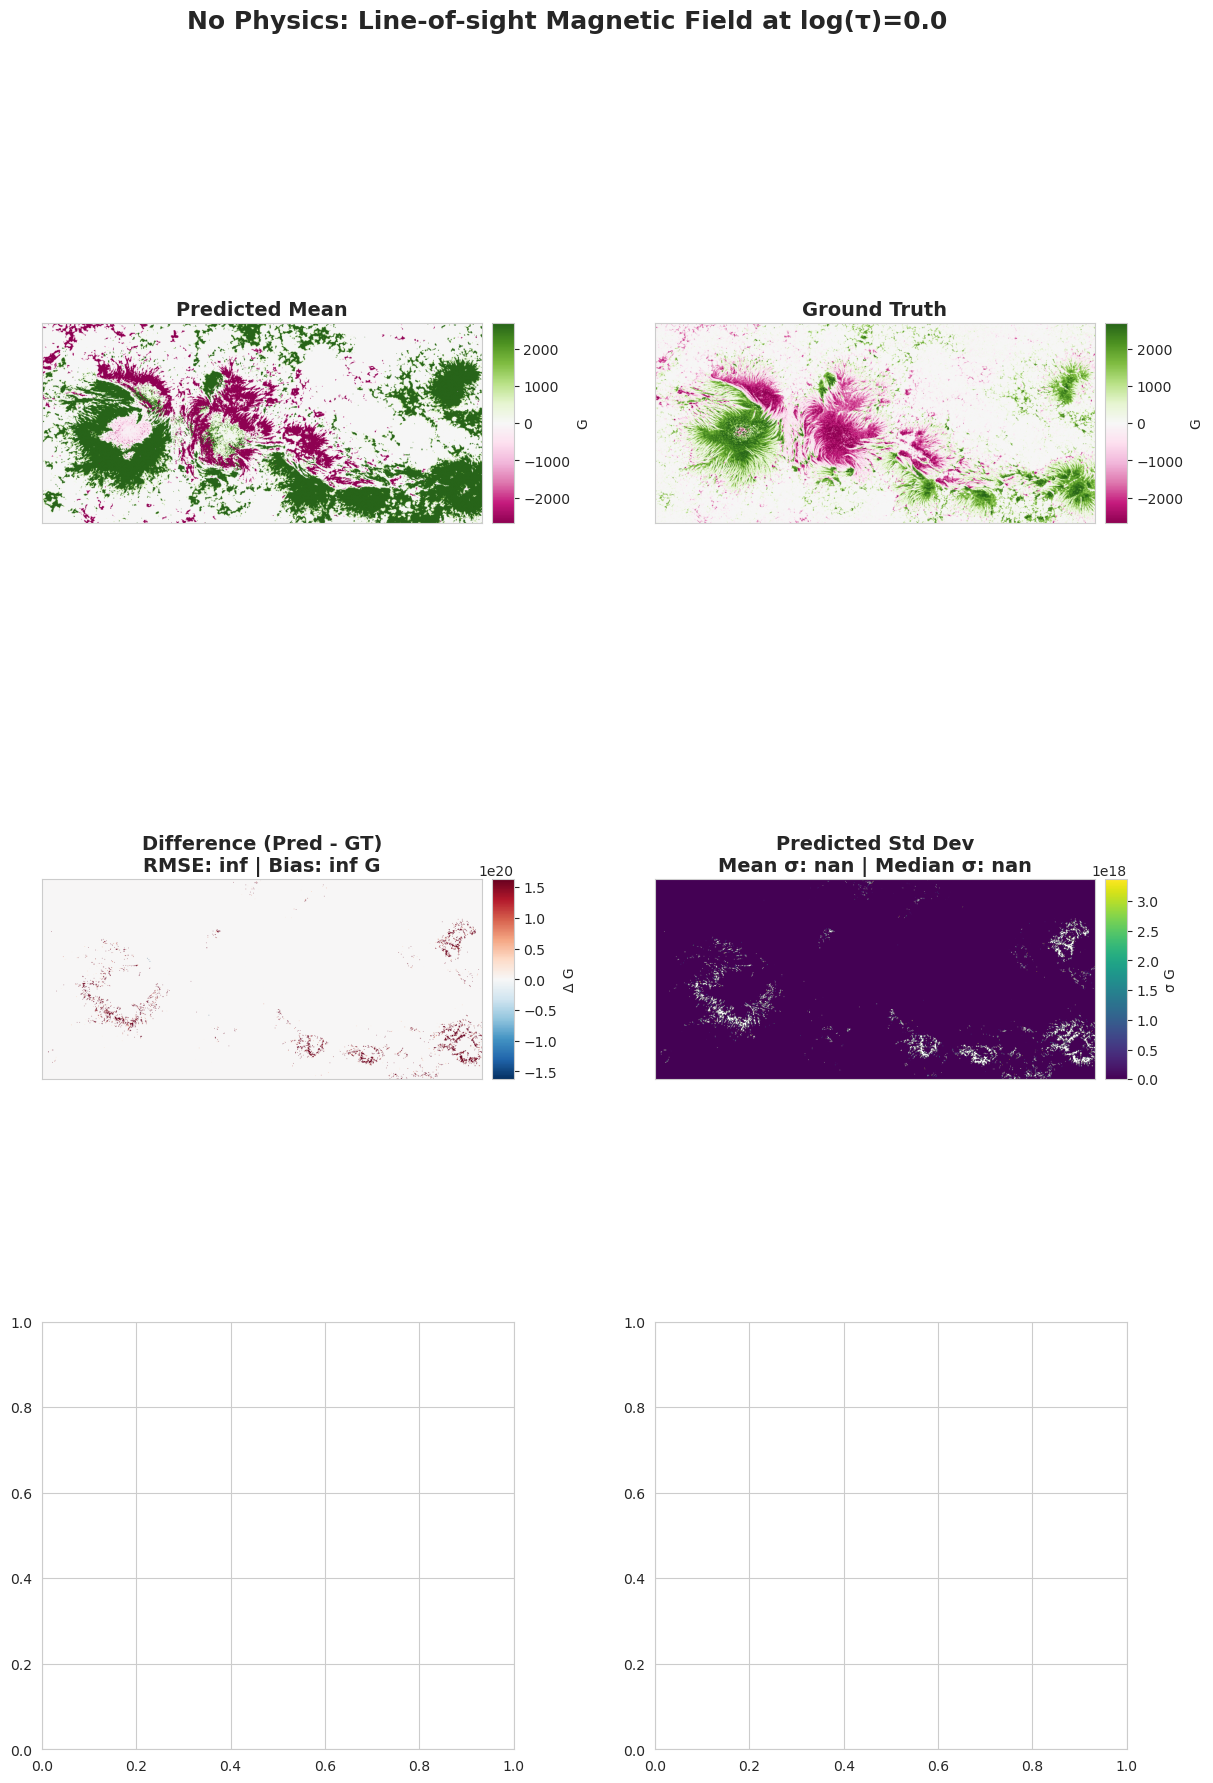

In [26]:
# Choose optical depth and parameter
logtau = np.arange(-2, 0.1, 0.1)

# Plot each model
for od_to_plot in modest_logtau:
    for mag_to_plot in ["Bz", "Vz", "T"]:
        for model_name, pred_data in all_predictions.items():
            try:
                filename = f"{pred_data['label'].lower().replace(' ', '_')}_comparison_{mag_to_plot}_logtau_{od_to_plot}.png"
                plot_prediction_comparison(
                    mean_atm=pred_data['mean'],
                    std_atm=pred_data['std'],
                    ground_truth=modest.spinor_atm,
                    mag_to_plot=mag_to_plot,
                    od_to_plot=od_to_plot,
                    logtau=logtau,
                    model_label=pred_data['label'],
                    figsize=(14, 20),
                    save_dir=images_save_path,
                    filename=filename
                )
                print(f"✓ Saved comparison plot for {pred_data['label']} at log(tau)={od_to_plot} for {mag_to_plot}")
            except Exception as e:
                print(f"✗ Failed to plot comparison for {pred_data['label']} at log(tau)={od_to_plot} for {mag_to_plot}: {e}")

## 8. Multi-Model Comparison

✓ Saved model comparison plot for T at log(tau)=-2.0
✓ Saved model comparison plot for Vz at log(tau)=-2.0
✓ Saved model comparison plot for Bz at log(tau)=-2.0
✓ Saved model comparison plot for T at log(tau)=-0.8
✓ Saved model comparison plot for Vz at log(tau)=-0.8


/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:269: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean(difference**2))


✓ Saved model comparison plot for Bz at log(tau)=-0.8
✓ Saved model comparison plot for T at log(tau)=0.0
✓ Saved model comparison plot for Vz at log(tau)=0.0
Error comparing models for Bz at log(tau)=0.0: supplied range of [-1.0296818050463054e+25, inf] is not finite


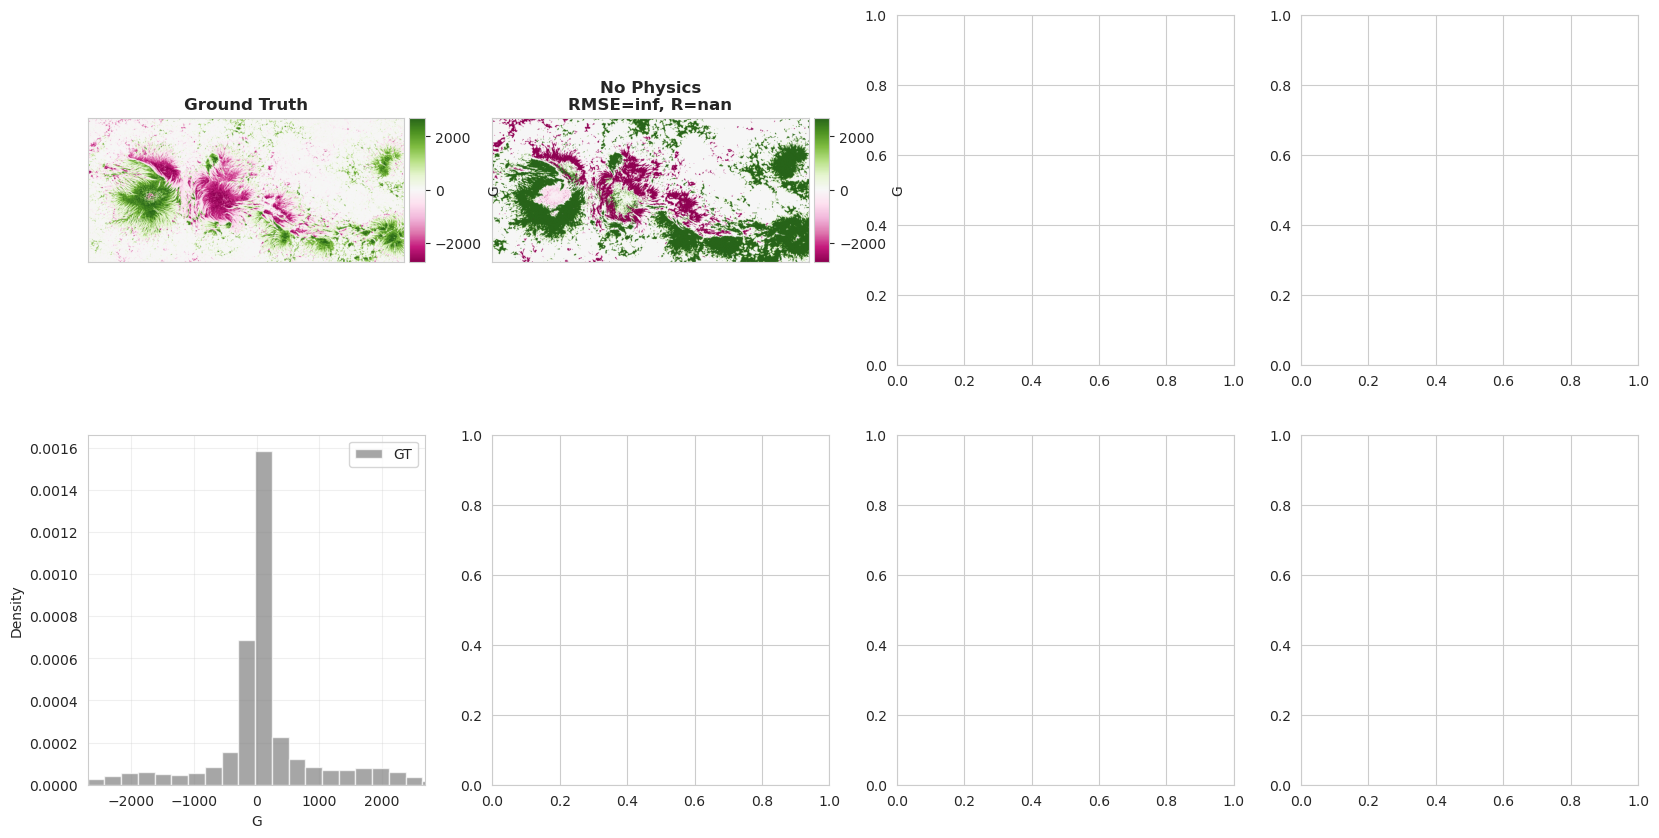

In [27]:
# Compare all models side-by-side
for od_to_plot in modest_logtau:
    for param in ['T', 'Vz', 'Bz']:
        filename = f"model_comparison_{param}_logtau_{od_to_plot}.png"
        try:
            compare_models_at_optical_depth(
                all_predictions=all_predictions,
                ground_truth=modest.spinor_atm,
                mag_to_plot=param,
                od_to_plot=od_to_plot,
                logtau=logtau,
                figsize=(20, 10),
                save_dir=images_save_path,
                filename=filename
            )
            print(f"✓ Saved model comparison plot for {param} at log(tau)={od_to_plot}")
        except Exception as e:
            print(f"Error comparing models for {param} at log(tau)={od_to_plot}: {e}")

## 9. Metrics Across Optical Depths

In [28]:
# Example 3: Compare all models with ground truth
for model_name, pred_data in all_predictions.items():
    filename = f"{pred_data['label'].lower().replace(' ', '_')}_mean_vs_optical_depth.png"
    print(f"\n{'='*80}")
    print(f"Model: {pred_data['label']}")
    print(f"{'='*80}")

    plot_mean_vs_optical_depth(
        mean_atm=pred_data['mean'],
        std_atm=pred_data['std'],
        logtau=logtau,
        figsize=(18, 6),
        log_scale={'T': False, 'Vz': False, 'Bz': False},
        ylims={'T': (2000, 7000), 'Vz': (-11, 7), 'Bz': (-2000, 2000)},
        ground_truth=modest.spinor_atm,
        save_dir=images_save_path,
        filename=filename
    )
    print(f"✓ Saved mean vs optical depth plot for {pred_data['label']}")


Model: No Physics



Ground Truth Comparison at Available Optical Depths

Temperature (K):
----------------------------------------------------------------------
  log(τ) =  -2.0:
    Ground Truth:      815.50 ±   739.42 K
    Model Pred:       5896.81 ±   347.10 K
    Difference:       5081.31 (+623.1%)
    RMSE:             5081.31 K
    RRMSE:           623.0948 (62309.48%)
    Correlation:       0.1278 (p=0.00e+00)
    Status:        ✗ OUTSIDE ±1σ uncertainty
  log(τ) =  -0.8:
    Ground Truth:     5227.71 ±   451.50 K
    Model Pred:       5896.81 ±   347.10 K
    Difference:        669.10 (+12.8%)
    RMSE:              669.10 K
    RRMSE:            12.7991 (1279.91%)
    Correlation:       0.0036 (p=3.58e-02)
    Status:        ✗ OUTSIDE ±1σ uncertainty
  log(τ) =   0.0:
    Ground Truth:     6107.60 ±   559.61 K
    Model Pred:       5896.81 ±   347.10 K
    Difference:       -210.79 (-3.5%)
    RMSE:              210.79 K
    RRMSE:             3.4512 (345.12%)
    Correlation:       0.0066 (p=1

/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4624: RuntimeWarning: invalid value encountered in subtract
  ym = y - ymean



Ground Truth Comparison at Available Optical Depths

Temperature (K):
----------------------------------------------------------------------
  log(τ) =  -2.0:
    Ground Truth:      815.50 ±   739.42 K
    Model Pred:       6144.19 ±   220.03 K
    Difference:       5328.69 (+653.4%)
    RMSE:             5328.69 K
    RRMSE:           653.4296 (65342.96%)
    Correlation:       0.2322 (p=0.00e+00)
    Status:        ✗ OUTSIDE ±1σ uncertainty
  log(τ) =  -0.8:
    Ground Truth:     5227.71 ±   451.50 K
    Model Pred:       6144.19 ±   220.03 K
    Difference:        916.48 (+17.5%)
    RMSE:              916.48 K
    RRMSE:            17.5311 (1753.11%)
    Correlation:       0.1488 (p=0.00e+00)
    Status:        ✗ OUTSIDE ±1σ uncertainty
  log(τ) =   0.0:
    Ground Truth:     6107.60 ±   559.61 K
    Model Pred:       6144.19 ±   220.03 K
    Difference:         36.59 (+0.6%)
    RMSE:               36.59 K
    RRMSE:             0.5991 (59.91%)
    Correlation:       0.0625 (p=3.

## 10. Seaborn-based Statistical Analysis

In [29]:
# 1. Separate jointplots for each model

for mag_to_plot in ["T", "Vz", "Bz"]:
    for od_to_plot in modest_logtau:
        try:
            print(f"\n{'='*80}")
            print(f"Separate Jointplots: {mag_to_plot}")
            print(f"{'='*80}")
            filename_prefix = f"jointplot_{mag_to_plot}_logtau_{od_to_plot}"
            plot_jointplot_comparison(
                all_predictions=all_predictions,
                ground_truth=modest.spinor_atm,
                mag_to_plot=mag_to_plot,
                od_val=od_to_plot,
                logtau=logtau,
                n_samples=10000,
                kind='reg',  # Options: 'scatter', 'hex', 'kde', 'reg',
                save_dir=images_save_path,
                filename_prefix=filename_prefix
            )
            print(f"✓ Saved jointplots for {mag_to_plot}")
        except Exception as e:
            print(f"Error plotting jointplots for {mag_to_plot}: {e}")


Separate Jointplots: T



No Physics - Temperature at log(τ)=-2.0
  Pearson R:   -0.6355 (p=0.00e+00)
  RMSE:        4703.99 K
  Bias:        2797.79 K
  Samples:     10,000

WFA Only - Temperature at log(τ)=-2.0
  Pearson R:   -0.6825 (p=0.00e+00)
  RMSE:        4257.21 K
  Bias:        2250.60 K
  Samples:     10,000

All Physics - Temperature at log(τ)=-2.0
  Pearson R:   -0.6950 (p=0.00e+00)
  RMSE:        9168.68 K
  Bias:        -1766.94 K
  Samples:     10,000
✓ Saved jointplots for T

Separate Jointplots: T

No Physics - Temperature at log(τ)=-0.8
  Pearson R:   0.2678 (p=9.26e-164)
  RMSE:        1211.58 K
  Bias:        -600.16 K
  Samples:     10,000

WFA Only - Temperature at log(τ)=-0.8
  Pearson R:   0.1848 (p=1.47e-77)
  RMSE:        588.47 K
  Bias:        -123.13 K
  Samples:     10,000

All Physics - Temperature at log(τ)=-0.8
  Pearson R:   0.4618 (p=0.00e+00)
  RMSE:        659.78 K
  Bias:        -93.52 K
  Samples:     10,000
✓ Saved jointplots for T

Separate Jointplots: T

No Physics - 

/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:1029: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean((pred_valid - gt_valid)**2))



No Physics - Line-of-sight Magnetic Field at log(τ)=0.0
  Pearson R:   0.0174 (p=8.11e-02)
  RMSE:        inf G
  Bias:        1882772689267316383067144192.00 G
  Samples:     10,000


/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:1029: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean((pred_valid - gt_valid)**2))



WFA Only - Line-of-sight Magnetic Field at log(τ)=0.0
  Pearson R:   -0.0150 (p=1.33e-01)
  RMSE:        inf G
  Bias:        -2032569247858688.00 G
  Samples:     10,000


/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:1029: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean((pred_valid - gt_valid)**2))



All Physics - Line-of-sight Magnetic Field at log(τ)=0.0
  Pearson R:   -0.0151 (p=1.31e-01)
  RMSE:        inf G
  Bias:        -1596873243696758578009341952.00 G
  Samples:     10,000
✓ Saved jointplots for Bz



Combined Jointplot: T



Combined Analysis: Temperature at log(τ)=-2.0

No Physics:
  Pearson R:   -0.6404 (p=0.00e+00)
  RMSE:        4700.25 K
  Bias:        2808.27 K
  Samples:     5,000

WFA Only:
  Pearson R:   -0.6794 (p=0.00e+00)
  RMSE:        4223.88 K
  Bias:        2206.03 K
  Samples:     5,000

All Physics:
  Pearson R:   -0.7004 (p=0.00e+00)
  RMSE:        9210.73 K
  Bias:        -1916.12 K
  Samples:     5,000
✓ Saved combined jointplot for T

Combined Jointplot: T

Combined Analysis: Temperature at log(τ)=-0.8

No Physics:
  Pearson R:   0.2889 (p=1.04e-96)
  RMSE:        1197.32 K
  Bias:        -605.90 K
  Samples:     5,000

WFA Only:
  Pearson R:   0.1975 (p=3.73e-45)
  RMSE:        576.31 K
  Bias:        -128.79 K
  Samples:     5,000

All Physics:
  Pearson R:   0.4510 (p=3.88e-249)
  RMSE:        660.20 K
  Bias:        -101.12 K
  Samples:     5,000
✓ Saved combined jointplot for T

Combined Jointplot: T

Combined Analysis: Temperature at log(τ)=0.0

No Physics:
  Pearson R:   -0.00

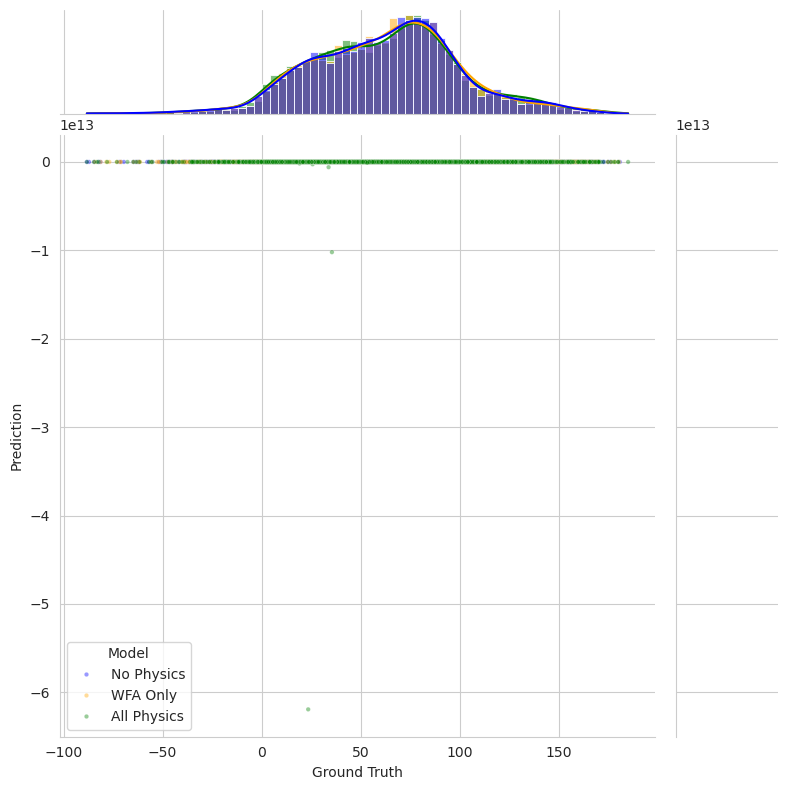

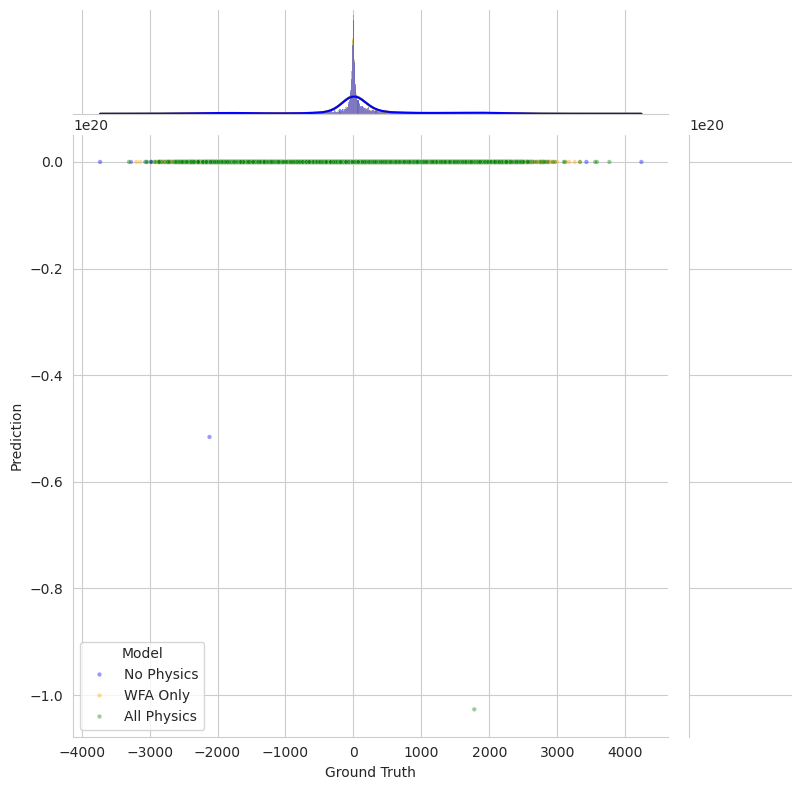

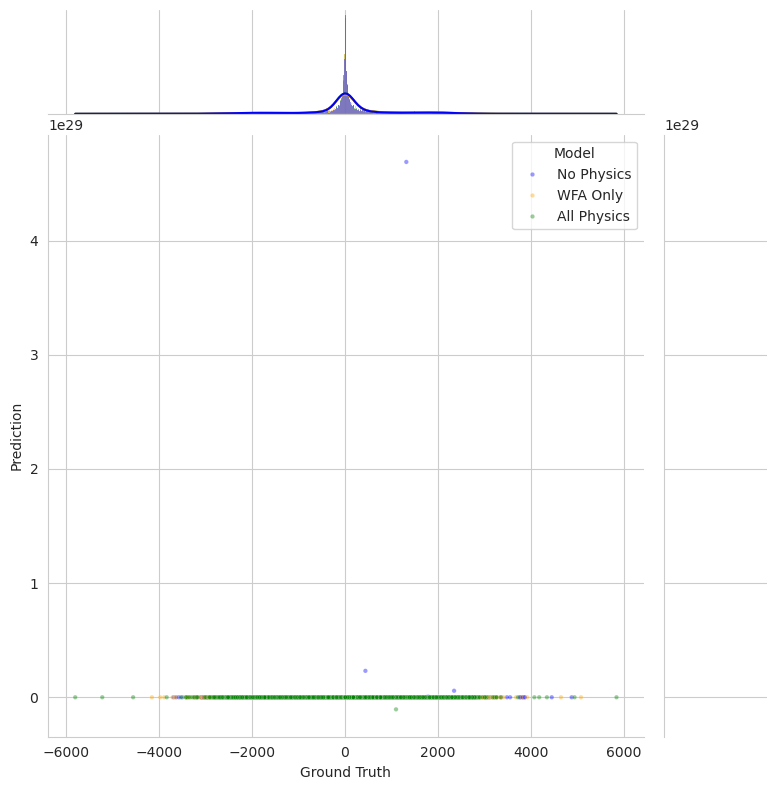

In [30]:
# 2. Combined jointplot with all models overlaid
for param in ['T', 'Vz', 'Bz']:
    for od_to_plot in modest_logtau:
        print(f"\n{'='*80}")
        print(f"Combined Jointplot: {param}")
        print(f"{'='*80}")
        filename = f"combined_jointplot_{param}_logtau_{od_to_plot}.png"
        try:
            plot_combined_jointplot(
                all_predictions=all_predictions,
                ground_truth=modest.spinor_atm,
                mag_to_plot=param,
                od_val=od_to_plot,
                logtau=logtau,
                n_samples=5000,
                save_dir=images_save_path,
                filename=filename
            )
            print(f"✓ Saved combined jointplot for {param}")
        except Exception as e:
            print(f"Error plotting combined jointplot for {param}: {e}")

## 11. Error Analysis by Magnitude

In [31]:
for param in ['T', 'Vz', 'Bz']:
    for od_to_plot in modest_logtau:
        filename = f"error_analysis_{param}_logtau_{od_to_plot}.png"
        analyze_error_by_magnitude(
            all_predictions=all_predictions,
            ground_truth=modest.spinor_atm,
            mag_to_analyze=param,  # Choose: "T", "Vz", or "Bz"
            od_val=od_to_plot,
            logtau=logtau,
            n_bins=20,
            plot_counts=False,
            use_absolute=False,
            rrmse_ylim=(0, 100),
            save_dir=images_save_path,
            filename=filename
        )
        print(f"✓ Saved error analysis plot for {param} at log(tau)={od_to_plot}")


Error Analysis by Signed Temperature at log(τ)=-2.0

No Physics:
----------------------------------------------------------------------
  Bin 1:  -595.70 -  -300.12 K  |  N: 2  |  GT_mean:  -512.80  |  MAE:  6554.04 ±  44.60  |  RRMSE: 1278.11%
  Bin 2:  -300.12 -    -4.53 K  |  N: 835  |  GT_mean:   -22.79  |  MAE:  5656.97 ± 571.96  |  RRMSE: 24945.02%
  Bin 3:    -4.53 -   291.06 K  |  N: 117,911  |  GT_mean:  +153.32  |  MAE:  5466.10 ± 329.18  |  RRMSE: 3571.35%
  Bin 4:   291.06 -   586.65 K  |  N: 49,278  |  GT_mean:  +414.04  |  MAE:  4897.11 ± 780.76  |  RRMSE: 1197.69%
  Bin 5:   586.65 -   882.23 K  |  N: 37,683  |  GT_mean:  +739.34  |  MAE:  3603.75 ± 1338.11  |  RRMSE: 519.94%
  Bin 6:   882.23 -  1177.82 K  |  N: 35,591  |  GT_mean: +1024.97  |  MAE:  2569.37 ± 1466.65  |  RRMSE: 288.64%
  Bin 7:  1177.82 -  1473.41 K  |  N: 27,696  |  GT_mean: +1318.89  |  MAE:  2889.49 ± 1898.78  |  RRMSE: 262.15%
  Bin 8:  1473.41 -  1769.00 K  |  N: 22,675  |  GT_mean: +1617.51  |  

/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:602: RuntimeWarning: overflow encountered in square
  rmse_bin = np.sqrt(np.mean(error_bin**2))
/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:663: RuntimeWarning: overflow encountered in square
  overall_rmse = np.sqrt(np.mean(error_valid**2))



Error Analysis by Signed Line-of-sight Magnetic Field at log(τ)=-0.8

No Physics:
----------------------------------------------------------------------
  Bin 1: -3985.40 - -3554.99 G  |  N: 7  |  GT_mean: -3709.98  |  MAE:  3680.65 ± 157.53  |  RRMSE:  99.30%
  Bin 2: -3554.99 - -3124.58 G  |  N: 57  |  GT_mean: -3245.42  |  MAE: 38540.77 ± 264814.97  |  RRMSE: 8245.61%
  Bin 3: -3124.58 - -2694.17 G  |  N: 672  |  GT_mean: -2835.18  |  MAE: 2018403065.25 ± 52038049792.00  |  RRMSE: 1836822400.00%
  Bin 4: -2694.17 - -2263.76 G  |  N: 3,674  |  GT_mean: -2433.92  |  MAE: 367854828.78 ± 14642282496.00  |  RRMSE: 601781750.00%
  Bin 5: -2263.76 - -1833.35 G  |  N: 7,822  |  GT_mean: -2029.53  |  MAE: 6843787030159609.00 ±    inf  |  RRMSE:    inf%
  Bin 6: -1833.35 - -1402.94 G  |  N: 9,360  |  GT_mean: -1627.29  |  MAE: 705001809300047744.00 ±    inf  |  RRMSE:    inf%
  Bin 7: -1402.94 -  -972.53 G  |  N: 6,600  |  GT_mean: -1193.98  |  MAE: 1712936366257891584.00 ±    inf  |  RRMSE:

/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:737: RuntimeWarning: overflow encountered in square
  rmse_bin = np.sqrt(np.mean(error_bin**2))
/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:187: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:761: RuntimeWarning: overflow encountered in square
  overall_rmse = np.sqrt(np.mean(error_valid**2))
/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:832: RuntimeWarning: overflow encountered in square
  rmse_bin = np.sqrt(np.mean(error_bin**2))
/scratchsan/observatorio/juag

  Bin 6: -1833.35 - -1402.94 G  |  N: 9,360  |  GT_mean: -1627.29  |  MAE: 132783.54 ± 2570177.25  |  RRMSE: 158152.58%
  Bin 7: -1402.94 -  -972.53 G  |  N: 6,600  |  GT_mean: -1193.98  |  MAE: 191401.52 ± 8878270.00  |  RRMSE: 743757.71%
  Bin 8:  -972.53 -  -542.12 G  |  N: 7,895  |  GT_mean:  -736.91  |  MAE:  8469.90 ± 152799.69  |  RRMSE: 20767.09%
  Bin 9:  -542.12 -  -111.71 G  |  N: 27,041  |  GT_mean:  -266.61  |  MAE:  1343.16 ± 67294.65  |  RRMSE: 25245.54%
  Bin 10:  -111.71 -   318.70 G  |  N: 208,823  |  GT_mean:   +28.61  |  MAE:   210.07 ± 10787.39  |  RRMSE: 21197.74%
  Bin 11:   318.70 -   749.11 G  |  N: 18,870  |  GT_mean:  +493.30  |  MAE: 11300.88 ± 851959.62  |  RRMSE: 172720.47%
  Bin 12:   749.11 -  1179.52 G  |  N: 10,064  |  GT_mean:  +958.06  |  MAE: 6890702.18 ± 571829312.00  |  RRMSE: 59690693.75%
  Bin 13:  1179.52 -  1609.93 G  |  N: 11,458  |  GT_mean: +1404.43  |  MAE: 347611778.38 ± 26345922560.00  |  RRMSE: 1876075400.00%
  Bin 14:  1609.93 -  2040.

/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/scipy/stats/_binned_statistic.py:609: RuntimeWarning: invalid value encountered in subtract
  delta = values[vv] - flatsum[binnumbers] / flatcount[binnumbers]
/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)



Error Analysis by Signed Line-of-sight Magnetic Field at log(τ)=0.0

No Physics:
----------------------------------------------------------------------
  Bin 1: -6428.83 - -5761.55 G  |  N: 7  |  GT_mean: -6061.97  |  MAE:  9293.04 ± 5201.58  |  RRMSE: 175.68%
  Bin 2: -5761.55 - -5094.27 G  |  N: 21  |  GT_mean: -5346.54  |  MAE:  7414.21 ± 7620.27  |  RRMSE: 198.86%
  Bin 3: -5094.27 - -4426.98 G  |  N: 37  |  GT_mean: -4762.73  |  MAE: 12288.90 ± 31826.84  |  RRMSE: 716.33%
  Bin 4: -4426.98 - -3759.70 G  |  N: 136  |  GT_mean: -4029.58  |  MAE: 348895.06 ± 1744057.50  |  RRMSE: 44138.87%
  Bin 5: -3759.70 - -3092.42 G  |  N: 781  |  GT_mean: -3339.12  |  MAE: 777818763.21 ± 17977452544.00  |  RRMSE: 538892150.00%
  Bin 6: -3092.42 - -2425.14 G  |  N: 4,382  |  GT_mean: -2679.17  |  MAE: 531218227239763.56 ± 26808749922451456.00  |  RRMSE: 1000833391001600.00%
  Bin 7: -2425.14 - -1757.86 G  |  N: 11,539  |  GT_mean: -2064.11  |  MAE: 1536019871748895744.00 ±    inf  |  RRMSE:    i

/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


  Bin 9: -1090.58 -  -423.29 G  |  N: 18,332  |  GT_mean:  -694.49  |  MAE: 1546921995505.19 ± 202138089160704.00  |  RRMSE: 29106801868800.00%
  Bin 10:  -423.29 -   243.99 G  |  N: 210,502  |  GT_mean:   -13.79  |  MAE: 20462339.54 ± 5525129728.00  |  RRMSE: 7407468000.00%
  Bin 11:   243.99 -   911.27 G  |  N: 35,223  |  GT_mean:  +502.45  |  MAE: 30876064567554956.00 ±    inf  |  RRMSE:    inf%
  Bin 12:   911.27 -  1578.55 G  |  N: 15,789  |  GT_mean: +1239.99  |  MAE: 4273119857492299776.00 ±    inf  |  RRMSE:    inf%
  Bin 13:  1578.55 -  2245.83 G  |  N: 16,935  |  GT_mean: +1902.47  |  MAE: 6512206237793485.00 ±    inf  |  RRMSE:    inf%
  Bin 14:  2245.83 -  2913.11 G  |  N: 7,380  |  GT_mean: +2503.13  |  MAE: 1301137469838.72 ± 51682243248128.00  |  RRMSE: 2065358028800.00%
  Bin 15:  2913.11 -  3580.40 G  |  N: 1,414  |  GT_mean: +3162.33  |  MAE: 6354630679.40 ± 238807171072.00  |  RRMSE: 7554291200.00%
  Bin 16:  3580.40 -  4247.68 G  |  N: 320  |  GT_mean: +3860.83  |  

<Figure size 640x480 with 0 Axes>

## 12. Uncertainty Quantification Analysis

In [32]:
# Run uncertainty analysis
for param in ['T', 'Vz', 'Bz']:
    for od_to_plot in modest_logtau:
        filename = f"uncertainty_vs_error_{param}_logtau_{od_to_plot}.png"
        plot_uncertainty_vs_error(
            all_predictions=all_predictions,
            ground_truth=modest.spinor_atm,
            mag_to_plot=param,
            od_val=od_to_plot,
            logtau=logtau,
            save_dir=images_save_path,
            filename=filename
        )
        print(f"✓ Saved uncertainty vs error plot for {param} at log(tau)={od_to_plot}")

✓ Saved uncertainty vs error plot for T at log(tau)=-2.0
✓ Saved uncertainty vs error plot for T at log(tau)=-0.8
✓ Saved uncertainty vs error plot for T at log(tau)=0.0
✓ Saved uncertainty vs error plot for Vz at log(tau)=-2.0
✓ Saved uncertainty vs error plot for Vz at log(tau)=-0.8
✓ Saved uncertainty vs error plot for Vz at log(tau)=0.0
✓ Saved uncertainty vs error plot for Bz at log(tau)=-2.0


/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4623: RuntimeWarning: invalid value encountered in subtract
  xm = x - xmean


✓ Saved uncertainty vs error plot for Bz at log(tau)=-0.8
✓ Saved uncertainty vs error plot for Bz at log(tau)=0.0
